# Progress Report 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

# Sklean
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from keras import layers, optimizers, regularizers, callbacks, models
from pathlib import Path

In [ ]:
# Confusion Matrix

GENRE_LABELS = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock",
]

def confusion_matrix_plot(model, X_test, y_test):

  cmd = ConfusionMatrixDisplay.from_predictions(
      y_test,
      model.predict(X_test).argmax(axis=1),
      cmap="magma",
      display_labels=GENRE_LABELS,
      xticks_rotation=45,)

  plt.show()

def per_class_error(model, X_test, y_test):
  y_pred = model.predict(X_test).argmax(axis=1)
  cm = confusion_matrix(y_test, y_pred)
  class_accuracy = cm.diagonal() / cm.sum(axis=1)

  print("\nPer-Class Accuracy:")
  for i, acc in enumerate(class_accuracy):
    print(f"{GENRE_LABELS[i]:<10} {acc * 100:>10.2f}%")

  print("\nPer-Class Error:")
  per_class_error = 1 - class_accuracy
  for i, acc in enumerate(per_class_error):
    print(f"{GENRE_LABELS[i]:<10} {acc * 100:>10.2f}%")

In [5]:
# Load in Train, Test, and Val Datasets
train_ds = np.load('../dataset/train.npz')
test_ds = np.load('../dataset/test.npz')
val_ds = np.load('../dataset/val.npz')

# Separate Spectrograms from Labels
X_train = train_ds['X']
y_train = train_ds['y']

X_val = val_ds['X']
y_val = val_ds['y']

X_test = test_ds['X']
y_test = test_ds['y']

In [6]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(45642, 128, 130)
(5673, 128, 130)
(5742, 128, 130)


In [18]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
for i in range(10):
    print(f"{GENRE_LABELS[i]:<20}{class_weight_dict[i]:>10.2f}")

blues                     5.71
classical                 5.71
country                   0.55
disco                     0.55
hiphop                    0.55
jazz                      5.71
metal                     5.71
pop                       0.55
reggae                    5.71
rock                      0.55


In [25]:
from music_classifier.inference.spec import SpecAugment

preprocessing_layers = keras.Sequential([
    # 1. Random Translation: Slighly shifts the audio in time (X-axis)
    layers.RandomTranslation(height_factor=0, width_factor=0.1, fill_mode='constant'),

    # 2. Gaussian Noise: Forces the model to ignore background static
    layers.GaussianNoise(0.05)
])

input_shape = (128, 130, 1)

In [23]:
CNN_25_input = layers.Input(shape=input_shape, name="Mel_Spec")

# Preprcoessing and Augmentation
x = preprocessing_layers(CNN_25_input)
x = SpecAugment(freq_mask_param=10, time_mask_param=10)(x)

# Block 1
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)

# Block 2
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)

# Block 3
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)

# Block 4 (Global Average Pooling)
x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

# Dense
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# Final Classification
CNN_25_output = layers.Dense(10, activation=None)(x)

# Build
CNN_25 = keras.Model(inputs=CNN_25_input, outputs=CNN_25_output)

# Compile
CNN_25.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)]
)

# Summary
CNN_25.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Mel_Spec (InputLayer)           │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spec_augment (SpecAugment)      │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,946 (1.62 MB)

 Trainable params: 422,986 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
model = keras.models.load_model(
    "../models/model.keras",
    custom_objects={"SpecAugment": SpecAugment},
    compile=True)

results = model.evaluate(X_test, y_test)

180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.6790 - loss: 0.9394 - sparse_top_k_categorical_accuracy: 0.9488
Accuracy: 0.68


180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step


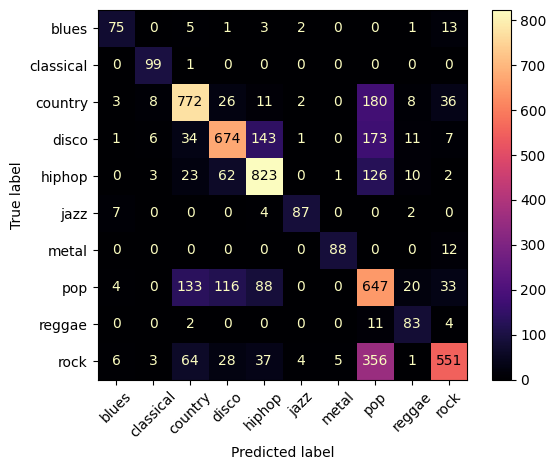

ValueError: You must call `compile()` before using the model.

In [ ]:
confusion_matrix_plot(model, X_test, y_test)
per_class_error(model, X_test, y_test)